In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path="/content/drive/MyDrive/iot files/iot files/"
os.chdir(path)
print("cur directory",os.getcwd())
print("files in it",os.listdir())

cur directory /content/drive/MyDrive/iot files/iot files
files in it ['normal.csv', 'train_test_network.csv', 'xss.csv', 'portscan.csv', 'extracted_flow_features.csv', 'combined_all_2.csv', 'injection.csv', 'mitm3.csv', 'dos.csv', 'ddos_small.csv', 'portscan2.csv', 'filtered_type_dos_backdoor1.csv', 'combined_all_1.csv', 'ddos_small_1.csv', 'injection3.csv', 'filtered_type_dos_backdoor.csv', 'injection2.csv', 'attack.csv', 'mitm.csv', 'dos2.csv', 'combined_all.csv', 'ddos.csv']


/tmp/ipykernel_11190/2430574892.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("label", group_keys=False).apply(lambda x: x.sample(min(len(x), 20000), random_state=6781))


                        duration  src_bytes  dst_bytes  missed_bytes  \
duration                1.000000   0.009534   0.007430      0.002411   
src_bytes               0.009534   1.000000   0.940137      0.152815   
dst_bytes               0.007430   0.940137   1.000000      0.159067   
missed_bytes            0.002411   0.152815   0.159067      1.000000   
src_pkts                0.133150  -0.000481   0.011291      0.074747   
src_ip_bytes            0.120855   0.001079   0.003595      0.021783   
dst_pkts                0.205056   0.014636   0.000704      0.003498   
dst_ip_bytes            0.217247   0.010368   0.012221      0.062752   
http_response_body_len  0.000749  -0.000178   0.016593      0.099361   

                        src_pkts  src_ip_bytes  dst_pkts  dst_ip_bytes  \
duration                0.133150      0.120855  0.205056      0.217247   
src_bytes              -0.000481      0.001079  0.014636      0.010368   
dst_bytes               0.011291      0.003595  0.000704 

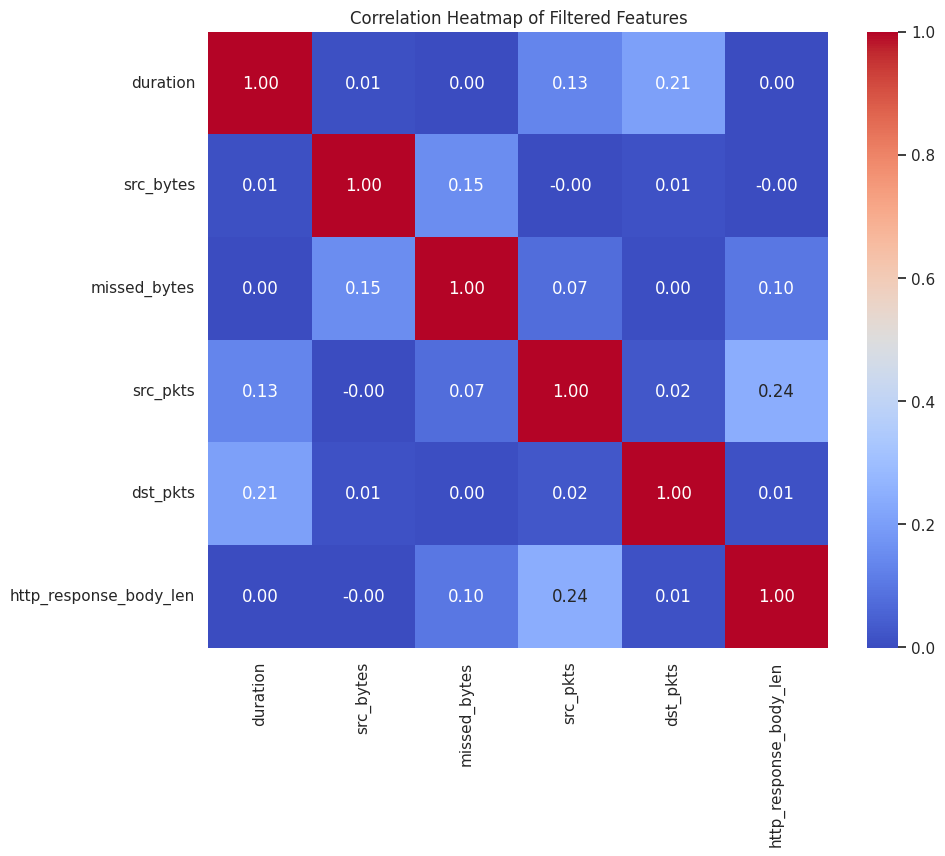

=== Original Data ===
<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 84033 to 40036
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   src_ip                  40000 non-null  object 
 1   src_port                40000 non-null  int64  
 2   dst_ip                  40000 non-null  object 
 3   dst_port                40000 non-null  int64  
 4   proto                   40000 non-null  object 
 5   service                 40000 non-null  object 
 6   duration                40000 non-null  float64
 7   src_bytes               40000 non-null  int64  
 8   dst_bytes               40000 non-null  int64  
 9   conn_state              40000 non-null  object 
 10  missed_bytes            40000 non-null  int64  
 11  src_pkts                40000 non-null  int64  
 12  src_ip_bytes            40000 non-null  int64  
 13  dst_pkts                40000 non-null  int64  
 14  dst_ip_bytes     

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectFdr
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SelectFpr
from sklearn.feature_selection import SelectFwe
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
import scipy.stats as stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import random

# ########################################################
# Read network data
# ########################################################
random.seed(6781)
np.random.seed(6781)

# Load dataset
data = pd.read_csv("train_test_network.csv")

# Sample 20,000 records from each class
data = data.groupby("label", group_keys=False).apply(lambda x: x.sample(min(len(x), 20000), random_state=6781))

# Manually balance the dataset before training
#attack_df = data[data['label'] == 1]
#normal_df = data[data['label'] == 0]

#min_count = min(len(attack_df), len(normal_df))
#balanced_df = pd.concat([
#    attack_df.sample(min_count, random_state=6781),
#   normal_df.sample(min_count, random_state=6781)
#])

# Shuffle the balanced dataset
#data = balanced_df.sample(frac=1, random_state=6781).reset_index(drop=True)


# Split data for processing
no_attributes = data.shape[1] - 2
dt = data.iloc[:, 0:no_attributes]   # data without classes
orignal_dt = data.iloc[:, 0:data.shape[1]-1]  # without timestamp and attack categories

# ########################################################
# Data conversion to numeric values
# ########################################################
cols = ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts',
        'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_response_body_len']

out = dt[cols].copy()

# ########################################################
# Data normalization
# ########################################################
scaler = MinMaxScaler()
dt_n = pd.DataFrame(scaler.fit_transform(out), columns=out.columns)

all_dt = pd.concat([dt_n, data.iloc[:, -1].reset_index(drop=True)], axis=1)
all_dt.columns = list(dt_n.columns) + ["label"]

# ########################################################
# Correlation analysis and Feature Selection
# ########################################################
correlationMatrix = dt_n.corr().fillna(0)

# Print correlation matrix
print(correlationMatrix)

# Identify highly correlated features
upper = correlationMatrix.where(np.triu(np.ones(correlationMatrix.shape), k=1).astype(bool))
highlyCorrelated = [column for column in upper.columns if any(upper[column].abs() > 0.5)]
print("Highly Correlated Attributes (cutoff=0.5):", highlyCorrelated)

# Filter less correlated features
dt_corr = dt_n.drop(columns=highlyCorrelated)
dt_corr_m = dt_corr.corr()

# Plot correlation heatmap
sns.set(style='white')
plt.figure(figsize=(10, 8))
sns.heatmap(dt_corr_m, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Filtered Features")
plt.show()

# Final dataset for classification
data_corr = pd.concat([dt_corr, data.iloc[:, -1].reset_index(drop=True)], axis=1)
data_corr.columns = list(dt_corr.columns) + ["label"]

# ########################################################
# Machine Learning for Classification
# ########################################################
# Split 70% training, 30% testing

filtered_train0, filtered_test, orignal_train0, orignal_test = train_test_split(
    data_corr, orignal_dt, test_size=0.3, random_state=3033, stratify=data_corr['label']
)
filtered_train, filtered_val, orignal_train, orignal_val = train_test_split(
    filtered_train0, orignal_train0, test_size=0.3, random_state=3033, stratify=filtered_train0['label']
)
# ########################################################
# Statistics and Data Overview
# ########################################################
print("=== Original Data ===")
print(data.info())
print(data.describe(include='all'))

print("=== Filtered Train Summary ===")
print(filtered_train.describe())

print("=== Filtered Test Summary ===")
print(filtered_test.describe())

print("=== Original Train Summary ===")
print(orignal_train.describe())

print("=== Original Test Summary ===")
print(orignal_test.describe())


In [ ]:
filtered_test.shape

(12000, 7)

In [ ]:
filtered_train.shape

(19600, 7)

In [ ]:
!pip install -f http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html h2o


Looking in links: http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 5.2 MB/s eta 0:00:00


In [ ]:
# Install h2o (uncomment if not already installed)
# !pip install h2o
import h2o
from h2o.estimators import H2OGradientBoostingEstimator, H2ORandomForestEstimator, H2ONaiveBayesEstimator, H2ODeepLearningEstimator, H2OXGBoostEstimator
from h2o.frame import H2OFrame

# Start H2O
h2o.init(ip="localhost", port=54321)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpet91k3o9
  JVM stdout: /tmp/tmpet91k3o9/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpet91k3o9/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.147 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
import pandas as pd

# Assume 'orignal_train' and 'orignal_test' already exist (loaded via pandas as per earlier code)

selected_columns = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'missed_bytes',
    'src_pkts',
    'src_ip_bytes',
    'dst_pkts',
    'dst_ip_bytes',
    'http_response_body_len',
    'label'
]

# Select only the required features + label
training = orignal_train[selected_columns].copy()
testing = orignal_test[selected_columns].copy()
validation=orignal_val[selected_columns].copy()
# Convert to H2OFrame
train_hex = h2o.H2OFrame(training)
test_hex = h2o.H2OFrame(testing)
validation_hex = h2o.H2OFrame(validation)
# Column index of label
label_no = train_hex.ncols - 1
no_features = train_hex.ncols - 1

# Convert label to factor (i.e., categorical)
train_hex[label_no] = train_hex[label_no].asfactor()
test_hex[label_no] = test_hex[label_no].asfactor()
validation_hex[label_no] = validation_hex[label_no].asfactor()
features = train_hex.col_names[:-1]
target = train_hex.col_names[-1]
valid=validation_hex.col_names[:-1]

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Random Forest
model_rf = H2ORandomForestEstimator(
    ntrees=200,
    max_depth=20,
    stopping_rounds=5,
    nfolds=10,
    seed=10000,
    keep_cross_validation_predictions=True,
    model_id="rf_model"
)

model_rf.train(x=features, y=target, training_frame=train_hex, validation_frame=validation_hex)

# GBM
model_gbm = H2OGradientBoostingEstimator(
    ntrees=100,
    max_depth=8,
    min_rows=5,
    learn_rate=0.05,
    distribution="multinomial",
    nfolds=10,
    keep_cross_validation_predictions=True,
    model_id="gbm_model"
)

model_gbm.train(x=features, y=target, training_frame=train_hex, validation_frame=validation_hex)

# Deep Learning
model_dl = H2ODeepLearningEstimator(
    hidden=[50, 50, 25],
    activation="RectifierWithDropout",
    input_dropout_ratio=0.2,
    l1=1e-5,
    l2=1e-5,
    epochs=200,
    nfolds=10,
    keep_cross_validation_predictions=True,
    model_id="dl_model"
)
model_dl.train(x=features, y=target, training_frame=train_hex, validation_frame=validation_hex)

# XGBoost
model_xgb = H2OXGBoostEstimator(
    ntrees=300,
    max_depth=8,
    learn_rate=0.03,
    sample_rate=0.8,
    col_sample_rate=0.8,
    nfolds=10,
    keep_cross_validation_predictions=True,
    seed=42,
    model_id="xgb_model"
)
model_xgb.train(x=features, y=target, training_frame=train_hex, validation_frame=validation_hex)



drf Model Build progress: |

/usr/local/lib/python3.12/dist-packages/h2o/estimators/estimator_base.py:192: RuntimeWarning: early stopping is enabled but neither score_tree_interval or score_each_iteration are defined. Early stopping will not be reproducible!
  warnings.warn(mesg["message"], RuntimeWarning)


██████████████████████████████████████████████████████| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
deeplearning Model Build progress: |█████████████████████████████████████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: xgb_model


Model Summary: 
    number_of_trees
--  -----------------
    300

ModelMetricsBinomial: xgboost
** Reported on train data. **

MSE: 0.00593056158691709
RMSE: 0.07701013950719145
LogLoss: 0.023269837017444416
Mean Per-Class Error: 0.00739795918367347
AUC: 0.9996977040816327
AUCPR: 0.9996872130347557
Gini: 0.9993954081632654

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.5108594298362732
       0     1     Error    Rate
-----  ----  ----  -------  ---------------
0      9715  85    0.0087   (85.0/9800.0)
1      60    9740  0.0061   (60.0/9800.0)
Total  9775  9825  0.0074   (145.0/19600.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.510859     0.992611  205
max f2                       0.201204     0.994593  265
max f0point5                 0.80361      0.994219  162
max accuracy                 0.510859     0.992602  205
max precision                0.999507     1         0
max recall                   0.02189      1         341
max specificity              0.999507     1         0
max absolute_mcc             0.510859     0.985207  205
max min_per_class_accuracy   0.633853     0.992245  192
max mean_per_class_accuracy  0.510859     0.992602  205
max tns                      0.999507     9800      0
max fns                      0.999507     8835      0
max fps                      0.00050565   9800      399
max tps                      0.02189      9800      341
max tnr                      0.999507     1         0
max fnr                      0.999507     0.901531  0
max fpr                      0.00050565   1         399
max tpr                      0.02189      1         341

Gains/Lift Table: Avg response rate: 50.00 %, avg score: 49.99 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score        cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  -----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.030102                    0.999512           2          2                  1                0.999512     1                           0.999512            0.0602041       0.0602041                  100       100                0.0602041
2        0.0445918                   0.999503           2          2                  1                0.999505     1                           0.99951             0.0289796       0.0891837                  100       100                0.0891837
3        0.0520408                   0.999464           2          2                  1                0.999479     1                           0.999506            0.014898        0.104082                   100       100                0.104082
4        0.100918                    0.999273           2          2                  1                0.999351     1                           0.999431            0.0977551       0.201837                   100       100                0.201837
5        0.154949                    0.998668           2          2                  1                0.998899     1                           0.999245            0.108061        0.309898                   100       100                0.309898
6        0.20199                     0.998329           2          2                  1                0.998494     1                           0.99907             0.0940816       0.40398                    100       100                0.40398
7        0.300051                    0.997309           2          2                  1    

In [ ]:
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator

# Define and train the ensemble
ensemble = H2OStackedEnsembleEstimator(
    base_models=[
        "rf_model",
        "gbm_model",
        "dl_model",
        "xgb_model"
    ],
    metalearner_algorithm="AUTO",  # You can try "gbm", "deeplearning", etc.
    model_id="stacked_ensemble_advanced"
)

# Train the ensemble model
ensemble.train(x=features, y=target, training_frame=train_hex, validation_frame=validation_hex)

# Evaluate performance on test data
perf_ensemble = ensemble.model_performance(test_data=test_hex)

from sklearn.metrics import classification_report, confusion_matrix

# Convert actual test labels to numpy array (as strings, to match H2O predictions)
actual = test_hex[target].as_data_frame().values.ravel().astype(str)


# Print results
print("\n================ Ensemble Model Evaluation ================\n")
print(f"AUC: {perf_ensemble.auc():.4f}")
print(f"Accuracy: {perf_ensemble.accuracy()[0][1]:.4f}")  # Best threshold accuracy
print(f"Train AUC: {ensemble.auc(train=True):.4f}")
print(f"Validation AUC: {ensemble.auc(valid=True):.4f}")
print("\n===========================================================\n")



stackedensemble Model Build progress: |██████████████████████████████████████████| (done) 100%

================ Ensemble Model Evaluation ================

AUC: 0.9989
Accuracy: 0.9902
Train AUC: 0.9998
Validation AUC: 0.9987




/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
# Step 1: Provide a new input row
import pandas as pd

new_input_data = pd.DataFrame([{
    'duration': 16.08859,
    'src_bytes': 108,
    'dst_bytes': 0,
    'missed_bytes': 0,
    'src_pkts': 2,
    'src_ip_bytes': 40,
    'dst_pkts': 0,
    'dst_ip_bytes': 0,
    'http_response_body_len': 0
}])

# Step 2: Convert to H2O Frame
import h2o
from h2o.frame import H2OFrame
h2o_input = h2o.H2OFrame(new_input_data)

# Step 3: Use your trained model to predict (e.g., GBM, RF, NB, DL)
# You can replace model_gbm with any other: model_dl, model_rf, model_nb
prediction = ensemble.predict(h2o_input)

# Step 4: Show the result
print(" Prediction Result (0 = Normal, 1 = Attack):")
print(prediction)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
 Prediction Result (0 = Normal, 1 = Attack):
  predict        p0         p1
        0  0.966961  0.0330386
[1 row x 3 columns]



In [ ]:
import pandas as pd
import h2o
from h2o.frame import H2OFrame

# Step 1: Load the full dataset
df = pd.read_csv("train_test_network.csv")

# Step 2: Randomly sample 10 rows
sample_df = df.sample(n=100)

# Step 3: Extract feature columns
selected_columns = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'http_response_body_len'
]

input_features = sample_df[selected_columns].copy()

# Step 4: Convert to H2OFrame
h2o.init(ip="localhost", port=54321)
h2o_input = H2OFrame(input_features)

# Step 5: Predict using the model
predictions = ensemble.predict(h2o_input)
predictions_df = predictions.as_data_frame()

# Step 6: Merge prediction with original rows and actual label/type
results = sample_df[['label']].reset_index(drop=True)
if 'category' in sample_df.columns:
    results['attack_type'] = sample_df['category'].reset_index(drop=True)
elif 'attack_type' in sample_df.columns:
    results['attack_type'] = sample_df['attack_type'].reset_index(drop=True)
else:
    results['attack_type'] = "N/A"

results['predicted'] = predictions_df['predict']
results['confidence_attack'] = predictions_df['p1']
results['confidence_normal'] = predictions_df['p0']

# Step 7: Display
print("\n Prediction Results (0 = Normal, 1 = Attack):")
print(results)


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,14 mins 17 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.093 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

 Prediction Results (0 = Normal, 1 = Attack):
    label attack_type  predicted  confidence_attack  confidence_normal
0       1         N/A          1           0.998620           0.001380
1       1         N/A          1           0.998620           0.001380
2       1         N/A          1           0.998226           0.001774
3       1         N/A          1           0.998270           0.001730
4       0         N/A          0           0.002634           0.997366
..    ...         ...        ...                ...                ...
95      1         N/A          1           0.997842           0.002158
96      0         N/A          0           0.001197           0.998803
97      1         N/A          1           0.988276           0.011724
98      1         N/A          1           0.991487  

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
import pandas as pd
import h2o
from h2o.frame import H2OFrame

# Step 1: Load your extracted PCAP features
df = pd.read_csv("filtered_type_dos_backdoor1.csv")

# Step 2: Select only the model-expected columns
selected_columns = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'http_response_body_len'
]
input_features = df[selected_columns].copy()

# Step 3: Convert to H2O Frame
h2o.init(ip="localhost", port=54321)
h2o_input = H2OFrame(input_features)

# Step 4: Predict using your trained model (e.g., model_rf)
predictions = ensemble.predict(h2o_input)
predictions_df = predictions.as_data_frame()

# Step 5: Merge predictions with input data
df['predicted'] = predictions_df['predict']
df['confidence_attack'] = predictions_df['p1']
df['confidence_normal'] = predictions_df['p0']

# Step 6: Show results
print("\n Predictions from Real PCAP Data:")
print(df[['duration', 'src_bytes', 'dst_bytes', 'predicted', 'confidence_attack', 'confidence_normal']].head(20))

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,16 mins 00 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.093 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

 Predictions from Real PCAP Data:
    duration  src_bytes  dst_bytes  predicted  confidence_attack  \
0          0       1530        336          1           0.906682   
1          0        784       8436          1           0.683894   
2          0     758700      30960          1           0.769902   
3          0      19646       1804          1           0.696217   
4          0        460        632          1           0.907556   
5          0        794        336          1           0.918396   
6          0        896       1282          1           0.909073   
7          0       1250      69740          1           0.673587   
8          0        936      53158          1           0.805678   
9          0        838      15816          1           0.663689   
10         0        784    

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
import pandas as pd
import h2o
from h2o.frame import H2OFrame

# Step 1: Load your extracted PCAP features
df = pd.read_csv("extracted_flow_features.csv")

# Step 2: Select only the model-expected columns
selected_columns = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'http_response_body_len'
]
input_features = df[selected_columns].copy()

# Step 3: Convert to H2O Frame
h2o.init(ip="localhost", port=54321)
h2o_input = H2OFrame(input_features)

# Step 4: Predict using your trained model (e.g., model_rf)
predictions = ensemble.predict(h2o_input)
predictions_df = predictions.as_data_frame()

# Step 5: Merge predictions with input data
df['predicted'] = predictions_df['predict']
df['confidence_attack'] = predictions_df['p1']
df['confidence_normal'] = predictions_df['p0']

# Step 6: Show results
print("\n Predictions from Real PCAP Data:")
print(df[['duration', 'src_bytes', 'dst_bytes', 'predicted', 'confidence_attack', 'confidence_normal']].head(40))

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,16 mins 30 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.092 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

 Predictions from Real PCAP Data:
     duration  src_bytes  dst_bytes  predicted  confidence_attack  \
0   16.384793        774          0          0           0.003219   
1   12.017220        198          0          0           0.025412   
2   12.017300        198          0          0           0.025412   
3    6.047488        124          0          0           0.015270   
4    6.047246        124          0          0           0.015270   
5    6.047053        124          0          0           0.015270   
6    6.047018        124          0          0           0.015270   
7    6.046982        124          0          0           0.015270   
8    6.046970        124          0          0           0.015270   
9    6.046967        124          0          0           0.015270   
10   6.046762   

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
import pandas as pd
import h2o
from h2o.frame import H2OFrame

# Step 1: Load your extracted PCAP features
df = pd.read_csv("mitm.csv")

# Step 2: Select only the model-expected columns
selected_columns = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'http_response_body_len'
]
input_features = df[selected_columns].copy()

# Step 3: Convert to H2O Frame
h2o.init(ip="localhost", port=54321)
h2o_input = H2OFrame(input_features)

# Step 4: Predict using your trained model (e.g., model_rf)
predictions = ensemble.predict(h2o_input)
predictions_df = predictions.as_data_frame()

# Step 5: Merge predictions with input data
df['predicted'] = predictions_df['predict']
df['confidence_attack'] = predictions_df['p1']
df['confidence_normal'] = predictions_df['p0']

# Step 6: Show results
print("\n Predictions from Real PCAP Data:")
print(df[['duration', 'src_bytes', 'dst_bytes', 'predicted', 'confidence_attack', 'confidence_normal']].head(40))

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,16 mins 43 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.092 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

 Predictions from Real PCAP Data:
   duration  src_bytes  dst_bytes  predicted  confidence_attack  \
0       0.0         86          0          1           0.922209   

   confidence_normal  
0           0.077791  


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
# ✅ Step 1: Import Libraries
import pandas as pd
import h2o
from h2o.frame import H2OFrame

# ✅ Step 2: Start H2O
h2o.init(ip="localhost", port=54321)

# ✅ Step 3: Load normal traffic only
normal_df = pd.read_csv("normal.csv")

# ✅ Step 4: Select only input features (no label)
selected_columns = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'http_response_body_len'
]
input_features = normal_df[selected_columns].copy()

# ✅ Step 5: Convert to H2OFrame
h2o_input = H2OFrame(input_features)

# ✅ Step 6: Predict using pre-trained model
predictions = ensemble.predict(h2o_input)
predictions_df = predictions.as_data_frame()

# ✅ Step 7: Merge predictions back to normal_df
normal_df['predicted'] = predictions_df['predict']
normal_df['confidence_attack'] = predictions_df['p1']
normal_df['confidence_normal'] = predictions_df['p0']

# ✅ Step 8: Display results
print("\n✅ Predictions on Normal Traffic Only:")
print(normal_df[['duration', 'src_bytes', 'dst_bytes', 'predicted', 'confidence_attack', 'confidence_normal']].head(40))

# ✅ Optional: Accuracy check if yo


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,16 mins 57 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.092 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

✅ Predictions on Normal Traffic Only:
    duration  src_bytes  dst_bytes  predicted  confidence_attack  \
0  54.597993       7119          0          0           0.007002   
1  35.234734        258          0          0           0.059957   
2   5.022148        153          0          0           0.011119   
3   0.000000         93          0          0           0.017927   

   confidence_normal  
0           0.992998  
1           0.940043  
2           0.988881  
3           0.982073  


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,17 mins 13 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_jpbe17
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.092 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


/tmp/ipykernel_11190/125442674.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("label", group_keys=False).apply(lambda x: x.sample(min(len(x), 20000), random_state=6781))


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
drf Model Build progress: |

/usr/local/lib/python3.12/dist-packages/h2o/estimators/estimator_base.py:192: RuntimeWarning: early stopping is enabled but neither score_tree_interval or score_each_iteration are defined. Early stopping will not be reproducible!
  warnings.warn(mesg["message"], RuntimeWarning)


██████████████████████████████████████████████████████| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
deeplearning Model Build progress: |█████████████████████████████████████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%
stackedensemble Model Build progress: |██████████████████████████████████████████| (done) 100%

=========== Ensemble Evaluation ===========
AUC: 0.9988424722222222
Accuracy: 0.9905833333333334
Precision: 1.0
Recall: 1.0
F1 Score: 0.99060134741745

Confusion Matrix:


,0,1,Error,Rate
0,5932.0,68.0,0.0113,(68.0/6000.0)
1,45.0,5955.0,0.0075,(45.0/6000.0)
Total,5977.0,6023.0,0.0094,(113.0/12000.0)


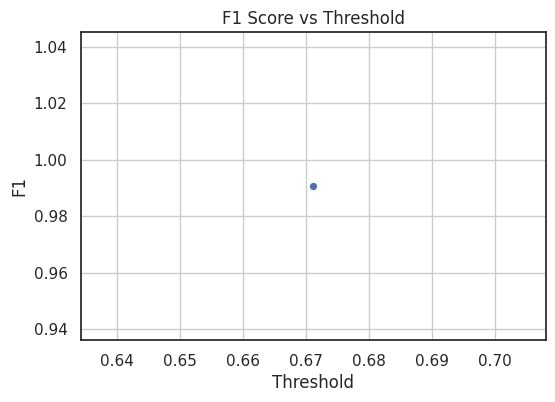

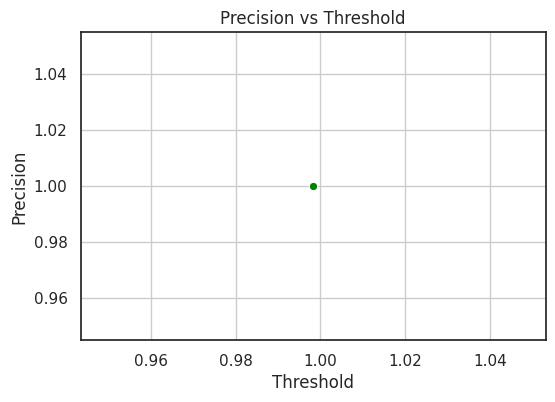

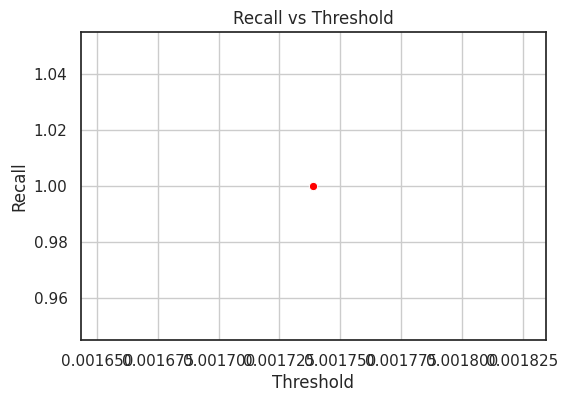

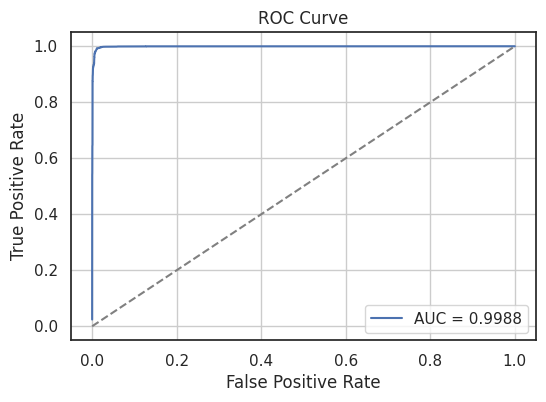

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

Prediction for single row:
   predict        p0        p1
0        0  0.844896  0.155104
Parse progress: |

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

Batch Prediction Results:
   label  predicted        p0        p1
0      0          0  0.998043  0.001957
1      1          1  0.006291  0.993709
2      0          0  0.998319  0.001681
3      0          0  0.998044  0.001956
4      0          0  0.998947  0.001053


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow a

In [ ]:
# ===============================================
# SECTION 1: IMPORTS & SETUP
# ===============================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import random

# H2O imports
import h2o
from h2o.frame import H2OFrame
from h2o.estimators import (
    H2OGradientBoostingEstimator, H2ORandomForestEstimator,
    H2ODeepLearningEstimator, H2OXGBoostEstimator,
    H2ONaiveBayesEstimator
)
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator

# Start H2O
h2o.init(ip="localhost", port=54321)

# Set random seed
random.seed(6781)
np.random.seed(6781)


# ===============================================
# SECTION 2: LOAD & BALANCE DATA
# ===============================================
data = pd.read_csv("train_test_network.csv")
data = data.groupby("label", group_keys=False).apply(lambda x: x.sample(min(len(x), 20000), random_state=6781))


# ===============================================
# SECTION 3: FEATURE SELECTION & NORMALIZATION
# ===============================================
selected_columns = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'http_response_body_len'
]

# Normalize selected features
scaler = MinMaxScaler()
data_norm = pd.DataFrame(scaler.fit_transform(data[selected_columns]), columns=selected_columns)
data_norm["label"] = data["label"].values

# Drop correlated features
corr_matrix = data_norm.drop(columns=['label']).corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_corr = [col for col in upper.columns if any(upper[col].abs() > 0.5)]
data_filtered = data_norm.drop(columns=highly_corr)

# Final filtered dataset
data_filtered['label'] = data["label"].values


# ===============================================
# SECTION 4: TRAIN-TEST SPLIT
# ===============================================
train_all, test, orig_train_all, orig_test = train_test_split(
    data_filtered, data[selected_columns + ['label']],
    test_size=0.3, random_state=3033, stratify=data_filtered['label']
)

train, val, orig_train, orig_val = train_test_split(
    train_all, orig_train_all, test_size=0.3,
    random_state=3033, stratify=train_all['label']
)


# ===============================================
# SECTION 5: H2O TRAINING
# ===============================================
train_hex = H2OFrame(orig_train)
val_hex = H2OFrame(orig_val)
test_hex = H2OFrame(orig_test)

label_col = "label"
features = [col for col in train_hex.col_names if col != label_col]
train_hex[label_col] = train_hex[label_col].asfactor()
val_hex[label_col] = val_hex[label_col].asfactor()
test_hex[label_col] = test_hex[label_col].asfactor()

# RF Model
model_rf = H2ORandomForestEstimator(ntrees=200, max_depth=20, stopping_rounds=5,
                                     nfolds=10, seed=10000, keep_cross_validation_predictions=True,
                                     model_id="rf_model")
model_rf.train(x=features, y=label_col, training_frame=train_hex, validation_frame=val_hex)

# GBM Model
model_gbm = H2OGradientBoostingEstimator(ntrees=100, max_depth=8, min_rows=5,
                                         learn_rate=0.05, distribution="multinomial", nfolds=10,
                                         keep_cross_validation_predictions=True, model_id="gbm_model")
model_gbm.train(x=features, y=label_col, training_frame=train_hex, validation_frame=val_hex)

# Deep Learning Model
model_dl = H2ODeepLearningEstimator(hidden=[50, 50, 25], activation="RectifierWithDropout",
                                    input_dropout_ratio=0.2, l1=1e-5, l2=1e-5,
                                    epochs=200, nfolds=10, keep_cross_validation_predictions=True,
                                    model_id="dl_model")
model_dl.train(x=features, y=label_col, training_frame=train_hex, validation_frame=val_hex)

# XGBoost Model
model_xgb = H2OXGBoostEstimator(ntrees=300, max_depth=8, learn_rate=0.03,
                                sample_rate=0.8, col_sample_rate=0.8, nfolds=10,
                                keep_cross_validation_predictions=True, seed=42, model_id="xgb_model")
model_xgb.train(x=features, y=label_col, training_frame=train_hex, validation_frame=val_hex)


# ===============================================
# SECTION 6: ENSEMBLE MODEL & EVALUATION
# ===============================================
ensemble = H2OStackedEnsembleEstimator(
    base_models=["rf_model", "gbm_model", "dl_model", "xgb_model"],
    metalearner_algorithm="AUTO",
    model_id="stacked_ensemble_advanced"
)
ensemble.train(x=features, y=label_col, training_frame=train_hex, validation_frame=val_hex)

perf = ensemble.model_performance(test_data=test_hex)
print("\n=========== Ensemble Evaluation ===========")
print("AUC:", perf.auc())
print("Accuracy:", perf.accuracy()[0][1])
print("Precision:", perf.precision()[0][1])
print("Recall:", perf.recall()[0][1])
print("F1 Score:", perf.F1()[0][1])
print("\nConfusion Matrix:")
perf.confusion_matrix().show()
print("===========================================\n")

# Plot F1 Score Table
f1_table = perf.F1()
f1_df = pd.DataFrame(f1_table, columns=["Threshold", "F1"])
plt.figure(figsize=(6,4))
sns.lineplot(data=f1_df, x="Threshold", y="F1", marker="o")
plt.title("F1 Score vs Threshold")
plt.grid(True)
plt.show()

# Plot Precision Table
prec_table = perf.precision()
prec_df = pd.DataFrame(prec_table, columns=["Threshold", "Precision"])
plt.figure(figsize=(6,4))
sns.lineplot(data=prec_df, x="Threshold", y="Precision", marker="o", color="green")
plt.title("Precision vs Threshold")
plt.grid(True)
plt.show()

# Plot Recall Table
recall_table = perf.recall()
recall_df = pd.DataFrame(recall_table, columns=["Threshold", "Recall"])
plt.figure(figsize=(6,4))
sns.lineplot(data=recall_df, x="Threshold", y="Recall", marker="o", color="red")
plt.title("Recall vs Threshold")
plt.grid(True)
plt.show()

# ROC Curve
fpr_tpr = perf.roc()
fpr, tpr = fpr_tpr[0], fpr_tpr[1]
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {perf.auc():.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


# ===============================================
# SECTION 7: SINGLE ROW PREDICTION
# ===============================================
new_data = pd.DataFrame([{
    'duration': 16.08859, 'src_bytes': 108, 'dst_bytes': 0, 'missed_bytes': 0,
    'src_pkts': 2, 'src_ip_bytes': 40, 'dst_pkts': 0, 'dst_ip_bytes': 0,
    'http_response_body_len': 0
}])
h2o_input = H2OFrame(new_data)
pred = ensemble.predict(h2o_input)
print("\nPrediction for single row:")
print(pred.as_data_frame())


# ===============================================
# SECTION 8: BATCH PREDICTION ON SAMPLE
# ===============================================
sample_df = data.sample(n=100)
sample_input = sample_df[selected_columns]
h2o_sample_input = H2OFrame(sample_input)
sample_preds = ensemble.predict(h2o_sample_input)
results = sample_df[['label']].reset_index(drop=True)
results['predicted'] = sample_preds.as_data_frame()['predict']
results['p0'] = sample_preds.as_data_frame()['p0']
results['p1'] = sample_preds.as_data_frame()['p1']
print("\nBatch Prediction Results:")
print(results.head())


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = sorted(list(set(y_true)))  # ensures correct label ordering
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
=== Random Forest ===


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


              precision    recall  f1-score   support

           0       0.50      0.50      0.50      6000
           1       0.50      0.50      0.50      6000

    accuracy                           0.50     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.50      0.50      0.50     12000



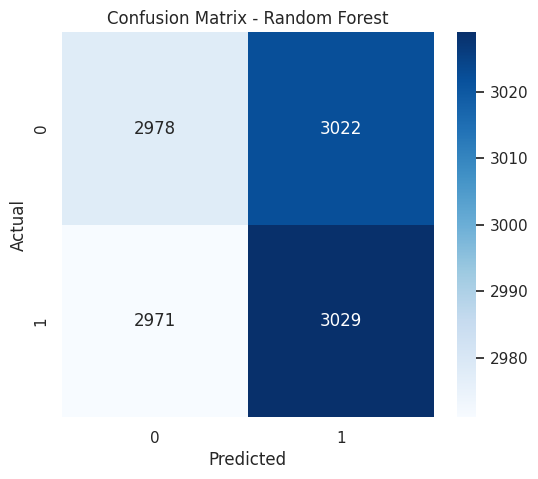

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      6000
           1       0.50      0.50      0.50      6000

    accuracy                           0.50     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.50      0.50      0.50     12000



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


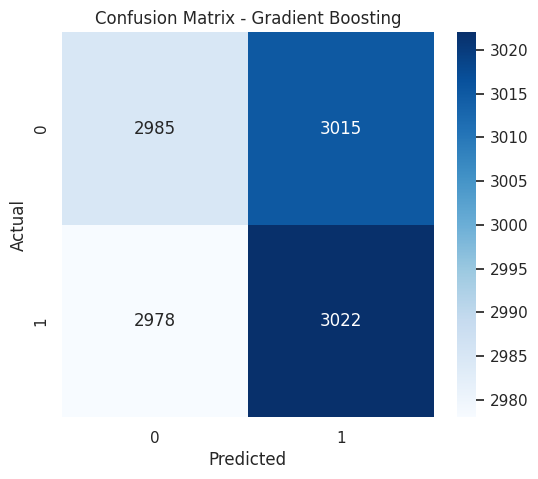

deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
=== Deep Learning ===


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


              precision    recall  f1-score   support

           0       0.50      0.10      0.16      6000
           1       0.50      0.90      0.64      6000

    accuracy                           0.50     12000
   macro avg       0.50      0.50      0.40     12000
weighted avg       0.50      0.50      0.40     12000



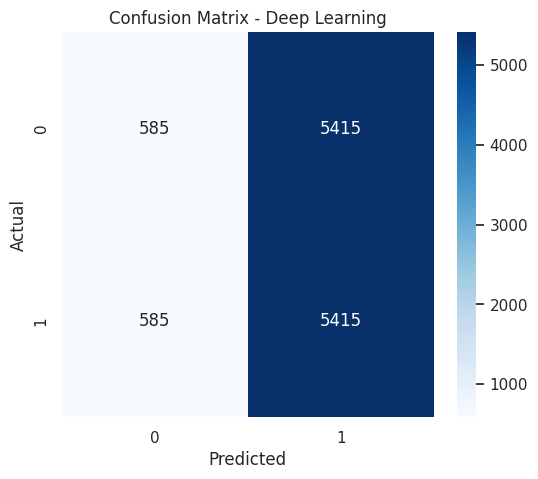

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
=== XGBoost ===


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


              precision    recall  f1-score   support

           0       0.50      0.50      0.50      6000
           1       0.50      0.50      0.50      6000

    accuracy                           0.50     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.50      0.50      0.50     12000



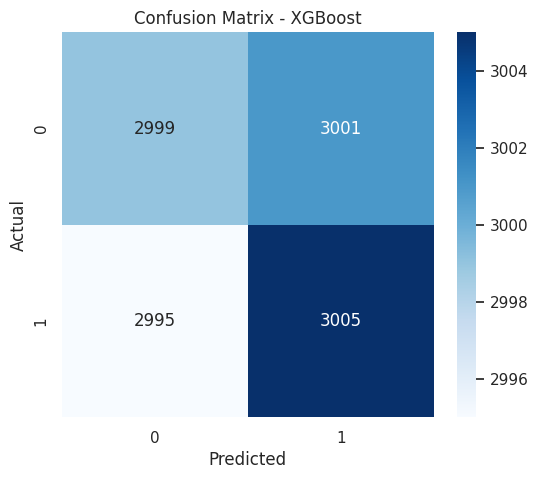

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
=== Stacked Ensemble ===
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      6000
           1       0.50      0.50      0.50      6000

    accuracy                           0.50     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.50      0.50      0.50     12000



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


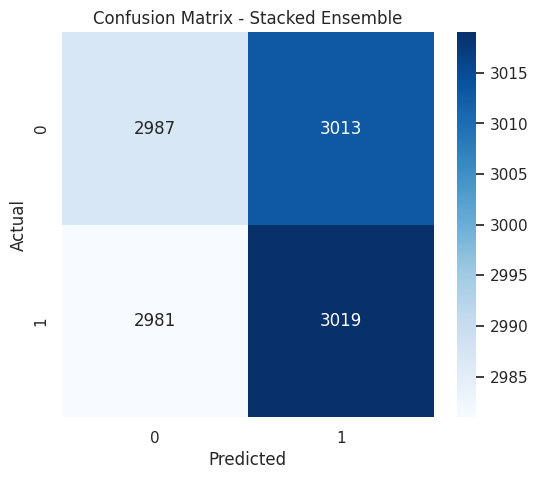

In [ ]:
# Random Forest
pred_rf = model_rf.predict(test_hex).as_data_frame()['predict'].astype(str)
print("=== Random Forest ===")
print(classification_report(actual, pred_rf))
plot_confusion_matrix(actual, pred_rf, "Random Forest")

# Gradient Boosting
pred_gbm = model_gbm.predict(test_hex).as_data_frame()['predict'].astype(str)
print("=== Gradient Boosting ===")
print(classification_report(actual, pred_gbm))
plot_confusion_matrix(actual, pred_gbm, "Gradient Boosting")

# Deep Learning
pred_dl = model_dl.predict(test_hex).as_data_frame()['predict'].astype(str)
print("=== Deep Learning ===")
print(classification_report(actual, pred_dl))
plot_confusion_matrix(actual, pred_dl, "Deep Learning")

# XGBoost
pred_xgb = model_xgb.predict(test_hex).as_data_frame()['predict'].astype(str)
print("=== XGBoost ===")
print(classification_report(actual, pred_xgb))
plot_confusion_matrix(actual, pred_xgb, "XGBoost")

# Stacked Ensemble
pred_ensemble = ensemble.predict(test_hex).as_data_frame()['predict'].astype(str)
print("=== Stacked Ensemble ===")
print(classification_report(actual, pred_ensemble))
plot_confusion_matrix(actual, pred_ensemble, "Stacked Ensemble")


In [ ]:
# Convert test labels and predictions to string (to match H2O format)
actual = test_hex[target].as_data_frame().values.ravel().astype(str)
pred_ensemble = ensemble.predict(test_hex).as_data_frame()['predict'].astype(str)


stackedensemble prediction progress: |

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


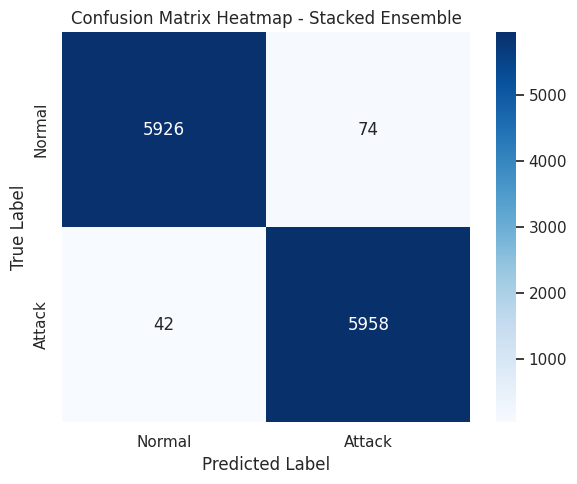

In [ ]:
# Create confusion matrix
cm = confusion_matrix(actual, pred_ensemble, labels=["0", "1"])

# Plot using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap - Stacked Ensemble")
plt.tight_layout()
plt.show()


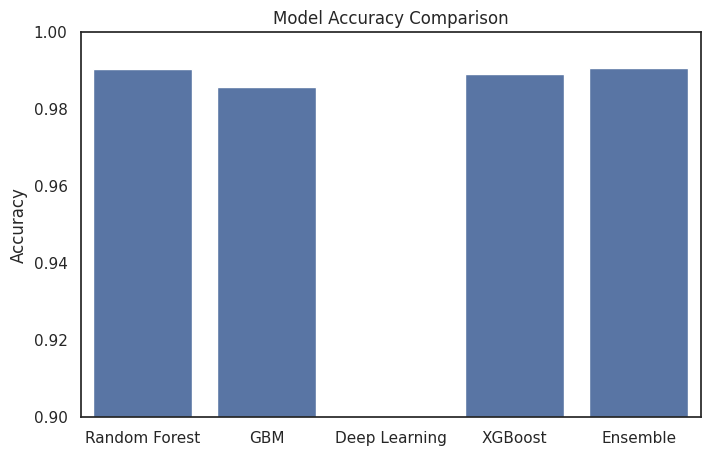

In [ ]:
model_names = ['Random Forest', 'GBM', 'Deep Learning', 'XGBoost', 'Ensemble']
accuracies = [
    model_rf.model_performance(test_hex).accuracy()[0][1],
    model_gbm.model_performance(test_hex).accuracy()[0][1],
    model_dl.model_performance(test_hex).accuracy()[0][1],
    model_xgb.model_performance(test_hex).accuracy()[0][1],
    ensemble.model_performance(test_hex).accuracy()[0][1],
]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.0)
plt.show()


stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


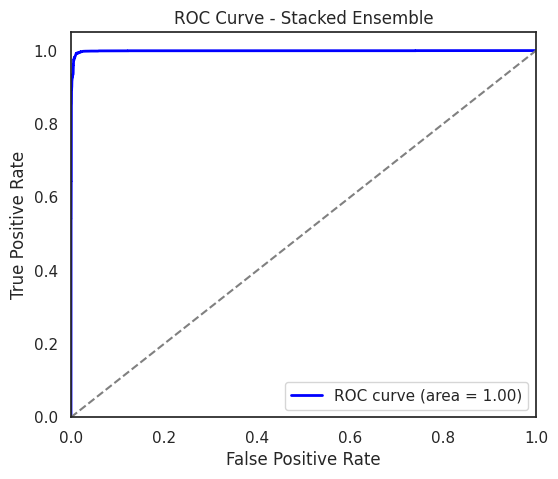

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
pred_df = ensemble.predict(test_hex).as_data_frame()
fpr, tpr, _ = roc_curve(actual.astype(int), pred_df['p1'])
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Ensemble')
plt.legend(loc="lower right")
plt.show()


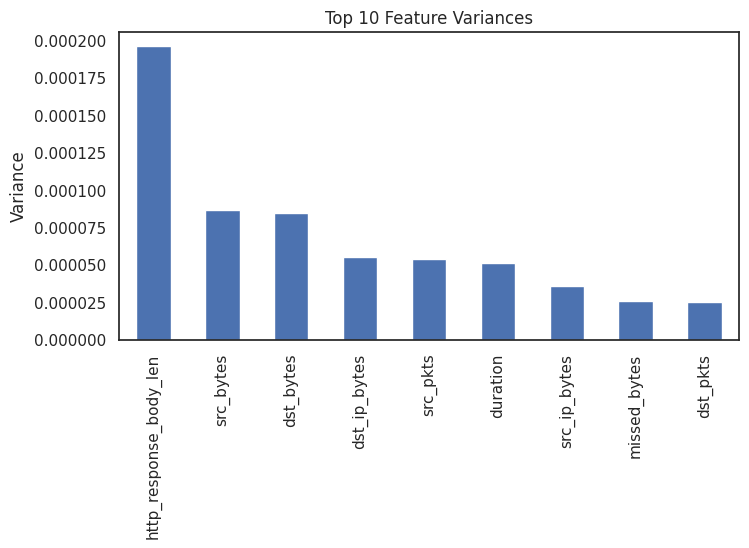

In [ ]:
variances = dt_n.var().sort_values(ascending=False)
variances.head(10).plot(kind='bar', figsize=(8,4), title="Top 10 Feature Variances")
plt.ylabel("Variance")
plt.show()
